<a href="https://colab.research.google.com/github/lightcode01-oss/IYB_INTERNSHIP/blob/main/Day_10_Random_Forest_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DAY 10 — Random Forest Classification Model

## YBI Foundation — Python, AI & Data Science Internship

### Objective

The objective of Day 10 is to train and evaluate a Random Forest
classification model for predicting student performance categories.

Random Forest combines multiple decision trees to create a more robust
ensemble model.

### Today's Work

- Load the dataset independently.
- Recreate the project target.
- Prevent target leakage.
- Prepare the feature groups.
- Perform a stratified train-test split.
- Build the preprocessing pipeline.
- Train a Random Forest classifier.
- Generate predictions.
- Evaluate the model.
- Analyze the confusion matrix.
- Compare Random Forest with previous models.
- Save the model comparison results.

No hyperparameter tuning will be performed today.

In [1]:
!pip -q install ucimlrepo

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
student_performance = fetch_ucirepo(id=320)

X = student_performance.data.features
y_original = student_performance.data.targets

df = X.copy()
df["G3"] = y_original["G3"]

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

Dataset loaded successfully.
Dataset shape: (649, 31)


In [3]:
def performance_category(grade):
    if grade < 10:
        return "Low"
    elif grade < 15:
        return "Medium"
    else:
        return "High"

df["performance_category"] = df["G3"].apply(
    performance_category
)

print(df["performance_category"].value_counts())

performance_category
Medium    418
High      131
Low       100
Name: count, dtype: int64


In [4]:
target = "performance_category"

X = df.drop(columns=[target])
y = df[target]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Feature shape: (649, 31)
Target shape: (649,)

Target distribution:
performance_category
Medium    418
High      131
Low       100
Name: count, dtype: int64


In [5]:
X_model = X.drop(columns=["G3"])

print("G3 present in model features:", "G3" in X_model.columns)
print("Final model feature count:", X_model.shape[1])

G3 present in model features: False
Final model feature count: 30


In [6]:
numerical_features = [
    "age",
    "absences"
]

ordinal_features = [
    "Medu",
    "Fedu",
    "traveltime",
    "studytime",
    "failures",
    "famrel",
    "freetime",
    "goout",
    "Dalc",
    "Walc",
    "health"
]

binary_features = [
    "school",
    "sex",
    "address",
    "famsize",
    "Pstatus",
    "schoolsup",
    "famsup",
    "paid",
    "activities",
    "nursery",
    "higher",
    "internet",
    "romantic"
]

nominal_features = [
    "Mjob",
    "Fjob",
    "reason",
    "guardian"
]

categorical_features = (
    binary_features +
    nominal_features
)

print("Numerical features:", len(numerical_features))
print("Ordinal features:", len(ordinal_features))
print("Categorical features:", len(categorical_features))

Numerical features: 2
Ordinal features: 11
Categorical features: 17


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 519
Testing samples: 130


In [8]:
categorical_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            categorical_encoder,
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features + ordinal_features
        )
    ],
    remainder="drop"
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [9]:
categorical_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            categorical_encoder,
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features + ordinal_features
        )
    ],
    remainder="drop"
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [10]:
random_forest = RandomForestClassifier(
    random_state=42
)

print("Random Forest classifier created successfully.")

Random Forest classifier created successfully.


In [11]:
random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", random_forest)
    ]
)

print("Random Forest pipeline created successfully.")

Random Forest pipeline created successfully.


In [12]:
random_forest_pipeline.fit(
    X_train,
    y_train
)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [13]:
y_pred = random_forest_pipeline.predict(X_test)

print("Predictions generated successfully.")

print("\nFirst 20 predictions:")
print(y_pred[:20])

Predictions generated successfully.

First 20 predictions:
['Medium' 'Medium' 'Medium' 'Medium' 'Low' 'Medium' 'Medium' 'Medium'
 'Medium' 'Medium' 'Medium' 'Medium' 'Medium' 'Medium' 'Medium' 'Medium'
 'Medium' 'Medium' 'Medium' 'Medium']


In [14]:
prediction_comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

prediction_comparison.head(20)

,Actual,Predicted
0,Medium,Medium
1,Low,Medium
2,Medium,Medium
3,Low,Medium
4,Medium,Low
5,Medium,Medium
6,High,Medium
7,Medium,Medium
8,Medium,Medium
9,Low,Medium


In [15]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Random Forest Accuracy:", round(accuracy, 4))
print("Random Forest Accuracy (%):", round(accuracy * 100, 2))

Random Forest Accuracy: 0.6231
Random Forest Accuracy (%): 62.31


In [16]:
precision = precision_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

print("Macro Precision:", round(precision, 4))

Macro Precision: 0.4371


In [17]:
recall = recall_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

print("Macro Recall:", round(recall, 4))

Macro Recall: 0.3557


In [18]:
f1 = f1_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

print("Macro F1 Score:", round(f1, 4))

Macro F1 Score: 0.3279


In [19]:
random_forest_results = pd.DataFrame({
    "Model": ["Random Forest"],
    "Accuracy": [accuracy],
    "Macro Precision": [precision],
    "Macro Recall": [recall],
    "Macro F1": [f1]
})

random_forest_results

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Random Forest,0.623077,0.437098,0.355678,0.327929


In [20]:
random_forest_results = pd.DataFrame({
    "Model": ["Random Forest"],
    "Accuracy": [accuracy],
    "Macro Precision": [precision],
    "Macro Recall": [recall],
    "Macro F1": [f1]
})

random_forest_results

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Random Forest,0.623077,0.437098,0.355678,0.327929


In [21]:
print(
    classification_report(
        y_test,
        y_pred,
        labels=["Low", "Medium", "High"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

         Low       0.33      0.10      0.15        20
      Medium       0.64      0.93      0.76        84
        High       0.33      0.04      0.07        26

    accuracy                           0.62       130
   macro avg       0.44      0.36      0.33       130
weighted avg       0.53      0.62      0.53       130



In [22]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["Low", "Medium", "High"]
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 2 18  0]
 [ 4 78  2]
 [ 0 25  1]]


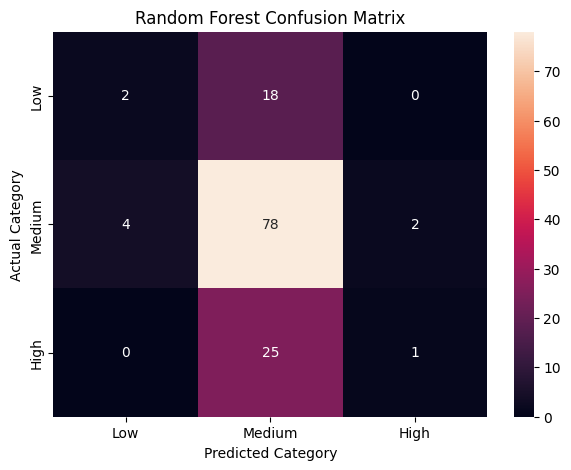

In [23]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.show()

In [24]:
y_train_pred = random_forest_pipeline.predict(X_train)

train_accuracy = accuracy_score(
    y_train,
    y_train_pred
)

test_accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Training Accuracy:", round(train_accuracy, 4))
print("Testing Accuracy:", round(test_accuracy, 4))

Training Accuracy: 1.0
Testing Accuracy: 0.6231


In [25]:
accuracy_gap = train_accuracy - test_accuracy

print("Training Accuracy:", round(train_accuracy, 4))
print("Testing Accuracy:", round(test_accuracy, 4))
print("Accuracy Gap:", round(accuracy_gap, 4))

Training Accuracy: 1.0
Testing Accuracy: 0.6231
Accuracy Gap: 0.3769


In [26]:
print("Actual test distribution:")
print(y_test.value_counts())

print("\nPredicted distribution:")
print(pd.Series(y_pred).value_counts())

Actual test distribution:
performance_category
Medium    84
High      26
Low       20
Name: count, dtype: int64

Predicted distribution:
Medium    121
Low         6
High        3
Name: count, dtype: int64


In [27]:
probabilities = random_forest_pipeline.predict_proba(X_test)

print("Probability matrix shape:", probabilities.shape)

print("\nFirst 5 probability predictions:")
print(probabilities[:5])

Probability matrix shape: (130, 3)

First 5 probability predictions:
[[0.16 0.2  0.64]
 [0.13 0.3  0.57]
 [0.24 0.2  0.56]
 [0.07 0.36 0.57]
 [0.16 0.42 0.42]]


In [28]:
classes = random_forest_pipeline.named_steps[
    "classifier"
].classes_

print("Class order:")
print(classes)

Class order:
['High' 'Low' 'Medium']


In [29]:
prediction_confidence = probabilities.max(axis=1)

confidence_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Confidence": prediction_confidence
})

confidence_df.head(10)

,Actual,Predicted,Confidence
0,Medium,Medium,0.64
1,Low,Medium,0.57
2,Medium,Medium,0.56
3,Low,Medium,0.57
4,Medium,Low,0.42
5,Medium,Medium,0.79
6,High,Medium,0.61
7,Medium,Medium,0.52
8,Medium,Medium,0.74
9,Low,Medium,0.52


In [30]:
prediction_confidence = probabilities.max(axis=1)

confidence_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Confidence": prediction_confidence
})

confidence_df.head(10)

,Actual,Predicted,Confidence
0,Medium,Medium,0.64
1,Low,Medium,0.57
2,Medium,Medium,0.56
3,Low,Medium,0.57
4,Medium,Low,0.42
5,Medium,Medium,0.79
6,High,Medium,0.61
7,Medium,Medium,0.52
8,Medium,Medium,0.74
9,Low,Medium,0.52


In [31]:
confidence_df.sort_values(
    by="Confidence",
    ascending=False
).head(10)

,Actual,Predicted,Confidence
115,Low,Medium,0.93
12,Medium,Medium,0.86
129,Medium,Medium,0.86
18,Medium,Medium,0.86
48,Medium,Medium,0.86
70,Medium,Medium,0.83
109,Medium,Medium,0.82
24,Medium,Medium,0.82
17,Medium,Medium,0.82
14,Medium,Medium,0.80


In [32]:
confidence_df.sort_values(
    by="Confidence",
    ascending=True
).head(10)

,Actual,Predicted,Confidence
49,Low,Medium,0.39
4,Medium,Low,0.42
52,Medium,Medium,0.45
21,Medium,Medium,0.47
28,Medium,Medium,0.47
76,Medium,Medium,0.48
114,Medium,Medium,0.49
113,Medium,Medium,0.49
94,Medium,Medium,0.50
103,Medium,Medium,0.50


In [35]:
logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            ColumnTransformer(
                transformers=[
                    (
                        "categorical",
                        OneHotEncoder(
                            handle_unknown="ignore",
                            sparse_output=False
                        ),
                        categorical_features
                    ),
                    (
                        "numerical",
                        "passthrough",
                        numerical_features + ordinal_features
                    )
                ],
                remainder="drop"
            )
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                random_state=42
            )
        )
    ]
)

logistic_pipeline.fit(X_train, y_train)

logistic_pred = logistic_pipeline.predict(X_test)

In [36]:
decision_tree_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            ColumnTransformer(
                transformers=[
                    (
                        "categorical",
                        OneHotEncoder(
                            handle_unknown="ignore",
                            sparse_output=False
                        ),
                        categorical_features
                    ),
                    (
                        "numerical",
                        "passthrough",
                        numerical_features + ordinal_features
                    )
                ],
                remainder="drop"
            )
        ),
        (
            "classifier",
            DecisionTreeClassifier(
                random_state=42
            )
        )
    ]
)

decision_tree_pipeline.fit(X_train, y_train)

decision_tree_pred = decision_tree_pipeline.predict(X_test)

In [37]:
def calculate_metrics(model_name, y_true, predictions):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_true,
            predictions
        ),
        "Macro Precision": precision_score(
            y_true,
            predictions,
            average="macro",
            zero_division=0
        ),
        "Macro Recall": recall_score(
            y_true,
            predictions,
            average="macro",
            zero_division=0
        ),
        "Macro F1": f1_score(
            y_true,
            predictions,
            average="macro",
            zero_division=0
        )
    }


model_comparison = pd.DataFrame([
    calculate_metrics(
        "Logistic Regression",
        y_test,
        logistic_pred
    ),
    calculate_metrics(
        "Decision Tree",
        y_test,
        decision_tree_pred
    ),
    calculate_metrics(
        "Random Forest",
        y_test,
        y_pred
    )
])

model_comparison

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Logistic Regression,0.669231,0.599889,0.507631,0.510613
1,Decision Tree,0.530769,0.446826,0.463919,0.450885
2,Random Forest,0.623077,0.437098,0.355678,0.327929


In [38]:
model_comparison_rounded = model_comparison.copy()

metric_columns = [
    "Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1"
]

model_comparison_rounded[metric_columns] = (
    model_comparison_rounded[metric_columns].round(4)
)

model_comparison_rounded

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Logistic Regression,0.6692,0.5999,0.5076,0.5106
1,Decision Tree,0.5308,0.4468,0.4639,0.4509
2,Random Forest,0.6231,0.4371,0.3557,0.3279


In [39]:
best_model_index = model_comparison["Macro F1"].idxmax()

best_model = model_comparison.loc[
    best_model_index,
    "Model"
]

best_f1 = model_comparison.loc[
    best_model_index,
    "Macro F1"
]

print("Current best model:", best_model)
print("Best Macro F1:", round(best_f1, 4))

Current best model: Logistic Regression
Best Macro F1: 0.5106


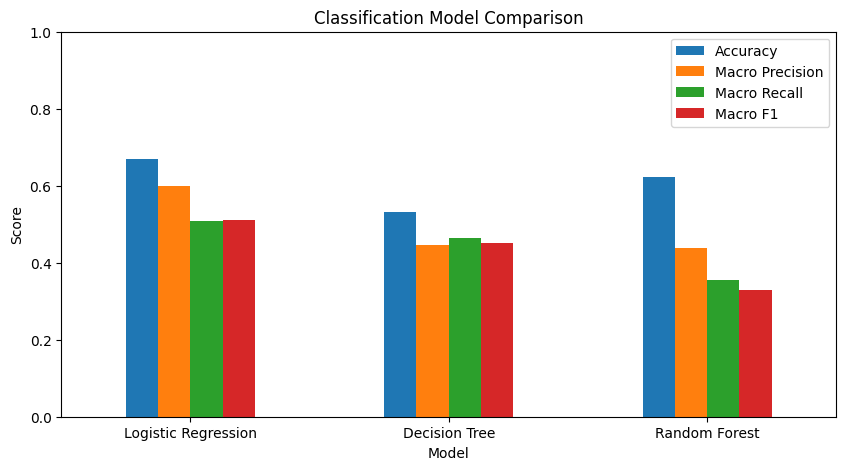

In [40]:
comparison_plot = model_comparison.set_index(
    "Model"
)[
    [
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1"
    ]
]

comparison_plot.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Classification Model Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.show()

In [41]:
model_ranking = model_comparison.sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)

model_ranking.insert(
    0,
    "Rank",
    range(1, len(model_ranking) + 1)
)

model_ranking

,Rank,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,1,Logistic Regression,0.669231,0.599889,0.507631,0.510613
1,2,Decision Tree,0.530769,0.446826,0.463919,0.450885
2,3,Random Forest,0.623077,0.437098,0.355678,0.327929


In [42]:
model_ranking.to_csv(
    "day_10_model_comparison.csv",
    index=False
)

print("Day 10 model comparison saved successfully.")

Day 10 model comparison saved successfully.


In [43]:
print("=" * 60)
print("DAY 10 RANDOM FOREST CHECK")
print("=" * 60)

print("Model tested:", "Random Forest")

print("\nTraining Accuracy:",
      round(train_accuracy, 4))

print("Testing Accuracy:",
      round(test_accuracy, 4))

print("Macro Precision:",
      round(precision, 4))

print("Macro Recall:",
      round(recall, 4))

print("Macro F1:",
      round(f1, 4))

print("\nCurrent best model by Macro F1:",
      best_model)

print("Best Macro F1:",
      round(best_f1, 4))

print("\nG3 leakage removed:",
      "G3" not in X_model.columns)

print("\nDay 10 completed successfully.")

DAY 10 RANDOM FOREST CHECK
Model tested: Random Forest

Training Accuracy: 1.0
Testing Accuracy: 0.6231
Macro Precision: 0.4371
Macro Recall: 0.3557
Macro F1: 0.3279

Current best model by Macro F1: Logistic Regression
Best Macro F1: 0.5106

G3 leakage removed: True

Day 10 completed successfully.


# Day 10 — Random Forest Findings

## Model Selection

A Random Forest Classifier was introduced as the third machine learning
algorithm in the project.

Random Forest is an ensemble learning method that combines multiple decision
trees to produce a more robust prediction model.

## Preprocessing

The same preprocessing strategy used in the previous experiments was
integrated with Random Forest using a Scikit-learn Pipeline.

This maintained consistency across the experiments.

## Evaluation

The Random Forest model was evaluated using:

- Accuracy
- Macro Precision
- Macro Recall
- Macro F1 Score
- Classification Report
- Confusion Matrix

## Model Comparison

Random Forest was compared with:

1. Logistic Regression
2. Decision Tree
3. Random Forest

All three models used the same train-test split and the same evaluation
metrics.

## Training and Testing Performance

Training and testing accuracy were compared to observe the initial
generalization behavior of the Random Forest model.

The training-testing difference will be investigated further during later
cross-validation and hyperparameter tuning stages.

## Prediction Confidence

Random Forest probability outputs were examined to understand the confidence
of individual predictions.

## Target Leakage

The `G3` feature was excluded from the model because
`performance_category` is directly derived from `G3`.

This prevents direct target leakage.

## Conclusion

Day 10 established Random Forest as the third baseline classification model.

The three baseline algorithms can now be compared before moving into more
advanced model experimentation and tuning.

# DAY 10 DEVELOPMENT LOG

## Work Completed

- Created an independent Day 10 notebook.
- Loaded the Student Performance dataset.
- Recreated the project target.
- Removed `G3` to prevent target leakage.
- Defined numerical, ordinal and categorical feature groups.
- Performed a stratified train-test split.
- Recreated the preprocessing pipeline.
- Created a Random Forest Classifier.
- Integrated preprocessing and Random Forest into one pipeline.
- Trained the Random Forest model.
- Generated test predictions.
- Calculated accuracy.
- Calculated macro precision.
- Calculated macro recall.
- Calculated macro F1 score.
- Generated a classification report.
- Generated a confusion matrix.
- Compared training and testing accuracy.
- Examined prediction confidence.
- Recreated Logistic Regression and Decision Tree baselines.
- Compared all three classification models.
- Ranked models using Macro F1.
- Saved the model comparison results.

## Key Learning

Random Forest is an ensemble method that combines multiple decision trees.
This can provide more robust predictions than relying on a single Decision
Tree.

Different algorithms can produce different results even when they use the
same prepared dataset.

## Important Project Decision

The baseline Random Forest model will be retained as an experimental
reference.

No hyperparameter tuning was performed during Day 10.

## Next Step

Day 11 will continue the classification experiment with another machine
learning algorithm and expand the model comparison stage.